In [113]:
import pandas as pd
df = pd.read_csv(r"smartcart_customers.csv")

In [114]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


In [115]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [116]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy = "mean")
df["Income"]=si.fit_transform(df[["Income"]])
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [117]:
df["Age"] = 2026 - df["Year_Birth"]

In [118]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [119]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [120]:
# Spending
df["Total_Spending"] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [121]:
# Children
df["Total_Children"] = df["Kidhome"]+df["Teenhome"]

In [122]:
# Education
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [123]:
df["Education"]=df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Postgraduate",
    "PhD" : "Postgraduate"
})
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [124]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [125]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone",
    "Divorced" : "Alone",
    "Widow" : "Alone",
    "Absurd" : "Alone",
    "YOLO" : "Alone",
})

In [126]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [127]:
drop_cols = ["ID","Year_Birth","Kidhome","Teenhome",'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'Dt_Customer','Marital_Status']
df_cleaned = df.drop(drop_cols,axis=1)

In [128]:
numerical_cols = df_cleaned.select_dtypes(include = ["number"])
numerical_cols.head()
numerical_cols.shape

(2240, 13)

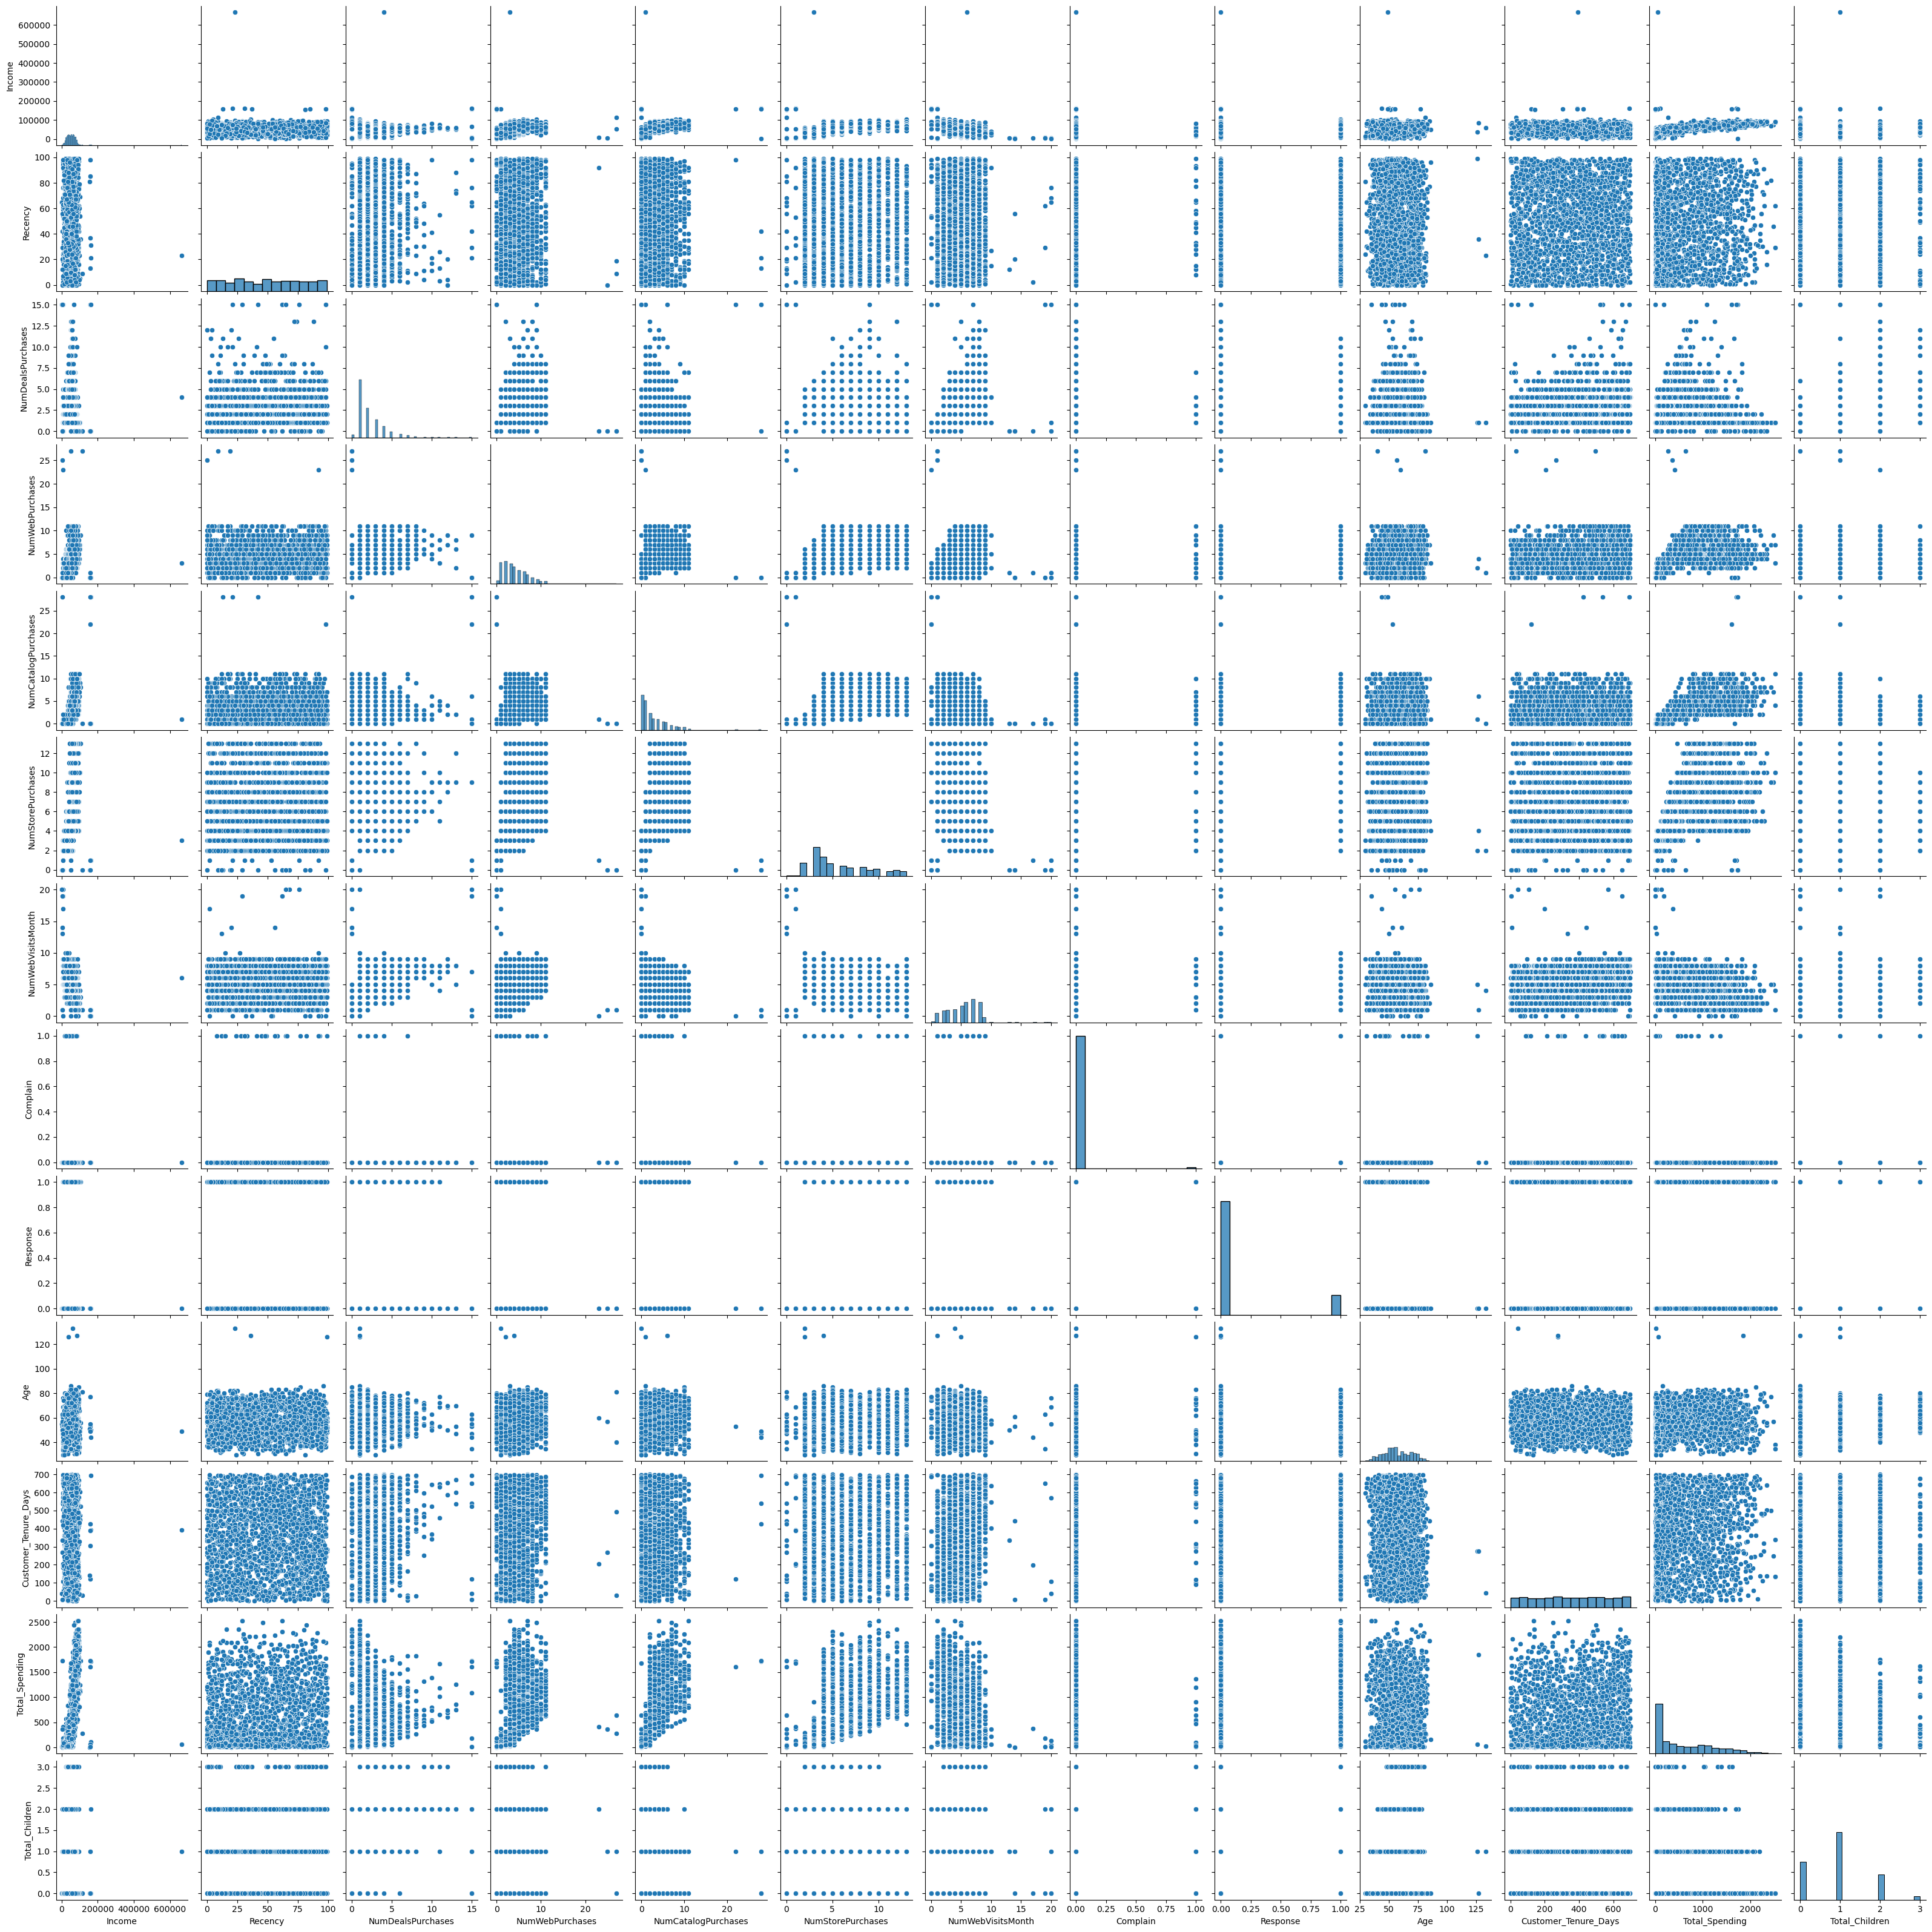

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(numerical_cols)
plt.show()


In [130]:
# Remove outliers
df_cleaned = df_cleaned[(df_cleaned["Income"]<600000)]
df_cleaned = df_cleaned[(df_cleaned["Age"]<100)]
df_cleaned = df_cleaned[(df_cleaned["NumCatalogPurchases"]<20)]
df_cleaned = df_cleaned[(df_cleaned["NumWebPurchases"]<20)]

In [131]:
df_cleaned.shape

(2228, 15)

# HeatMap

In [132]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

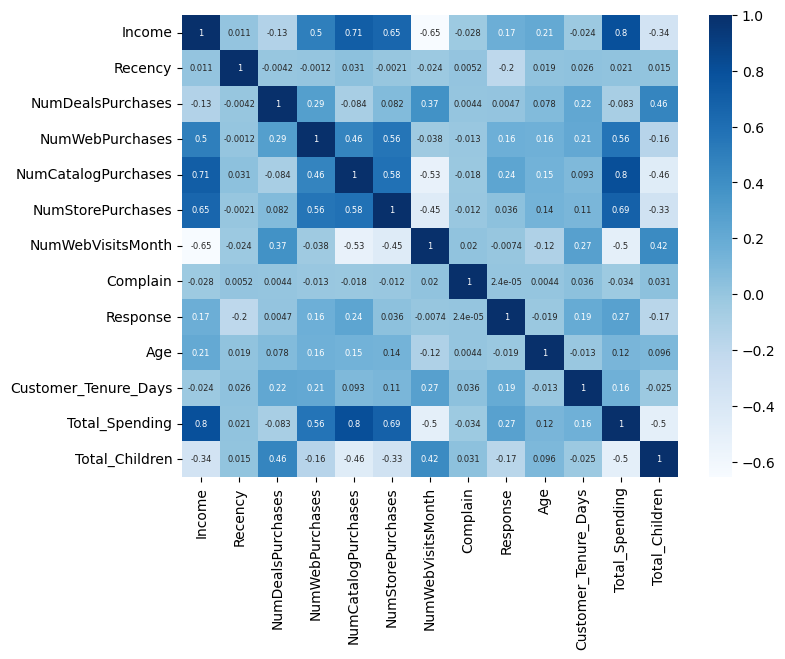

In [133]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size":6},
    cmap = "Blues"
)

In [134]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_cols = ["Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])
enc_cols

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2228 stored elements and shape (2228, 2)>

In [135]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns= ohe.get_feature_names_out(cat_cols),
                      index=df_cleaned.index)
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [136]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_encoded["Education"] = le.fit_transform(df_cleaned["Education"])
df_encoded["Education"].head()

0    0
1    0
2    0
3    0
4    1
Name: Education, dtype: int64

In [137]:
df_encoded.shape

(2228, 16)

# Scaling

In [138]:
from sklearn.preprocessing import StandardScaler

In [139]:
x = df_encoded 

In [140]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Visualize

In [141]:
x_scaled.shape

(2228, 16)

In [142]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scaled)

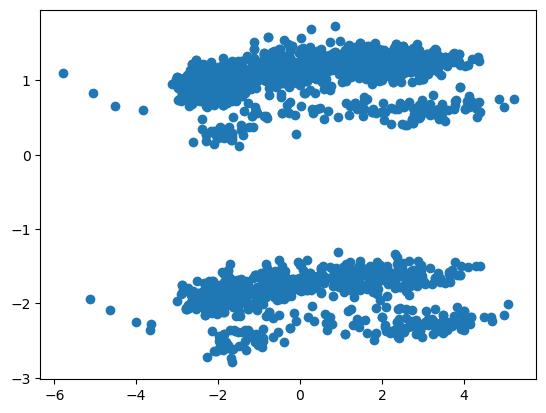

In [143]:
plt.scatter(x_pca[:,0],x_pca[:,1])

In [144]:
pca.explained_variance_ratio_

array([0.267534 , 0.1280818])

In [145]:
pca = PCA(n_components = 3)
x_pca = pca.fit_transform(x_scaled)
pca.explained_variance_ratio_

array([0.267534  , 0.1280818 , 0.11692277])

Text(0.5, 0.92, '3d projection')

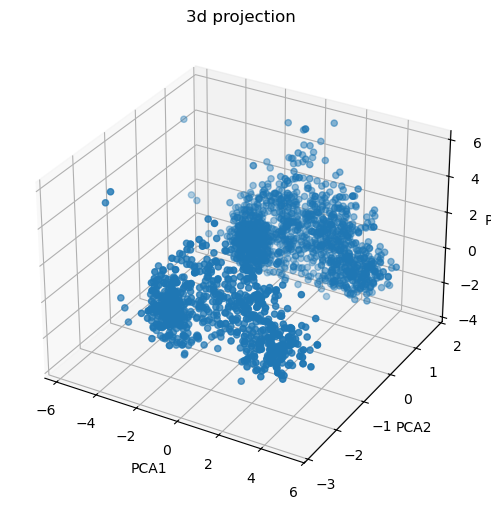

In [146]:
#plot
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Analyze K Value

### ELBOW METHOD

In [148]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []
for k in range (1,11):
    kmeans = KMeans(n_clusters = k,random_state = 42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [153]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [154]:
print("best k=",optimal_k)


best k= 4


In [ ]:
#plot 
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")

# Silhouette Score

In [157]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca,labels)
    scores.append(score)

Text(0, 0.5, 'Silhouette Score')

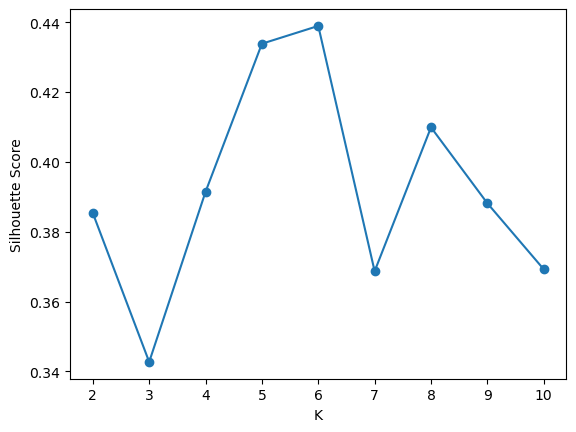

In [158]:
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")

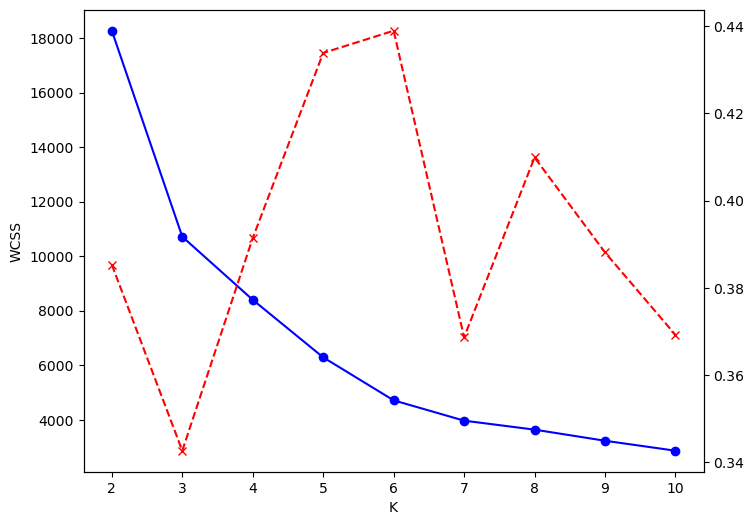

In [160]:
k_range = range(2,11)
fig,ax1 = plt.subplots(figsize = (8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color ="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")
ax2 = ax1.twinx() # same x-axis
ax2.plot(k_range,scores[:len(k_range)],marker="x",color ="red",linestyle="--")

In [162]:
# K_means
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(x_pca)

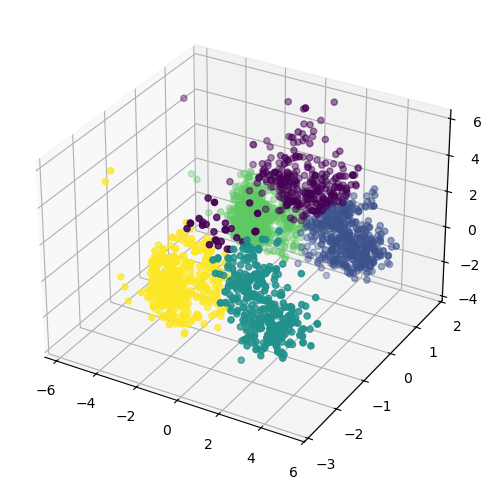

In [164]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c=labels_kmeans)

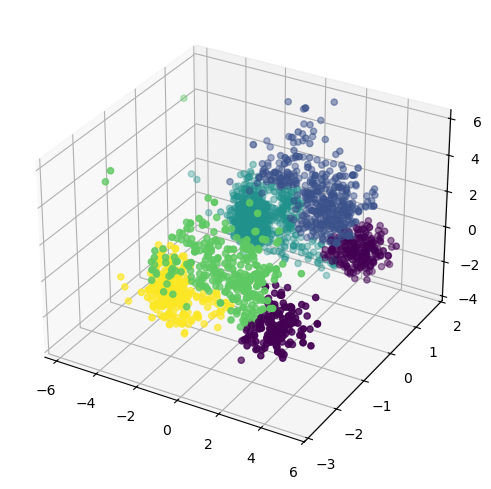

In [168]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters=5, linkage="ward")
labels_agg = agg_clf.fit_predict(x_pca)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c=labels_agg)

# Characterisation of clusters

In [169]:
x["cluster"] = labels_agg

<Axes: xlabel='cluster', ylabel='count'>

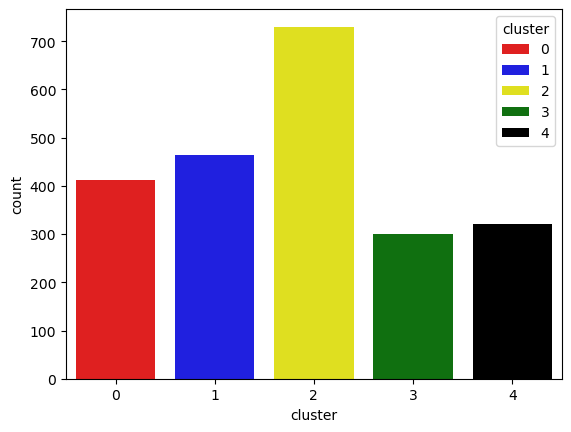

In [171]:
pal = ["red", "blue", "yellow", "green","black"]
sns.countplot(x=x["cluster"], palette=pal, hue=x["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

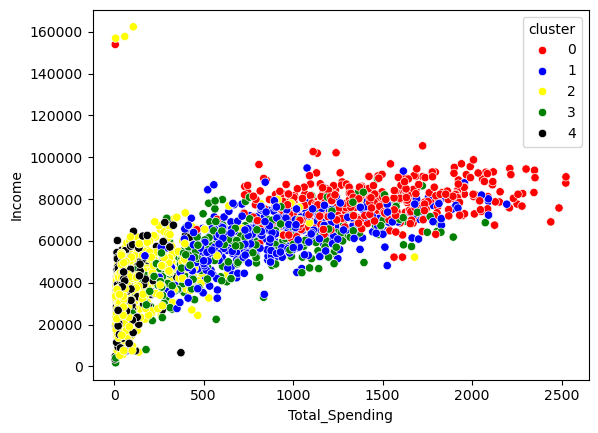

In [172]:
# Income & Spending patterns
sns.scatterplot(x=x["Total_Spending"], y=x["Income"], hue=x["cluster"], palette=pal)

In [174]:
# Cluster Summary
cluster_summary = x.groupby("cluster").mean()
print(cluster_summary)

         Education        Income    Recency  NumDealsPurchases  \
cluster                                                          
0         0.530266  78525.543590  50.927361           0.983051   
1         0.573276  60848.232229  49.790948           3.687500   
2         0.679452  37239.218512  48.760274           1.916438   
3         0.551495  55111.968448  45.445183           3.491694   
4         0.668750  34667.717213  50.375000           1.840625   

         NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
cluster                                                            
0               4.723971             6.297821           8.648910   
1               6.484914             3.523707           7.997845   
2               2.315068             0.701370           3.498630   
3               5.980066             3.116279           7.023256   
4               1.837500             0.506250           3.143750   

         NumWebVisitsMonth  Complain  Response        Age  \